# Gün 14 Demo - Chunking Yöntemleri ve Benzerlik Metrikleri

Raporda chunking'in RAG'in en çok küçümsenen ama sonucu en çok etkileyen adımı
olduğunu yazdım, benzerlik metriklerinin de normalize edilmiş vektörlerde aynı
sıralamayı verdiğini iddia ettim. İkisini de burada deneyerek gösteriyorum.

Bu demo gün 15'teki projenin doğrudan hazırlığı: orada yazacağım parçalama
fonksiyonunun provası burada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("numpy:", np.__version__)

numpy: 2.5.1


## 1. Adım - Örnek metni hazırlıyorum

Kurgusal bir e-ticaret şirketinin iade politikası metni yazdım. Kısa ama içinde
gerçek bir belgede olan şeyler var: başlıklar, paragraflar, madde işaretleri ve
tam sayısal bilgiler (gün sayısı, tutar).

Sayısal bilgileri özellikle koydum, çünkü parçalama sırasında bir bilginin ortadan
bölünüp bölünmediğini en net onlarla görebiliyorum.

In [2]:
metin = """İade ve Değişim Politikası

Satın aldığınız ürünü teslim aldığınız tarihten itibaren 14 gün içinde iade
edebilirsiniz. İade talebi oluşturmak için müşteri panelindeki Siparişlerim
bölümünü kullanmanız gerekir.

Kargo Ücreti

Ürün ayıplı ise kargo ücreti tarafımızca karşılanır. Cayma hakkı kapsamındaki
iadelerde ise kargo ücreti 49,90 TL olup müşteriye aittir. Bu tutar iade edilecek
bedelden düşülerek hesabınıza aktarılır.

İade Edilemeyen Ürünler

Kişisel bakım ürünleri, iç giyim ve ambalajı açılmış kozmetik ürünleri hijyen
gerekçesiyle iade alınmaz. Dijital kod içeren ürünler kod görüntülendikten sonra
iade edilemez.

Para İadesi Süresi

Onaylanan iadelerde bedel, ödeme yönteminize göre 3 ila 10 iş günü içinde iade
edilir. Kredi kartı iadelerinde süre bankanıza bağlı olarak uzayabilir."""

print("metin uzunluğu:", len(metin), "karakter")
print("satır sayısı  :", len(metin.split(chr(10))))
print()
print(metin[:200] + "...")

metin uzunluğu: 797 karakter
satır sayısı  : 22

İade ve Değişim Politikası

Satın aldığınız ürünü teslim aldığınız tarihten itibaren 14 gün içinde iade
edebilirsiniz. İade talebi oluşturmak için müşteri panelindeki Siparişlerim
bölümünü kullanmanız...


## 2. Adım - Sabit boyutlu parçalama (örtüşmesiz)

En basit yöntem: metni her N karakterde bir kes. Hiçbir şeye bakmıyor, sadece
sayıyor.

Örtüşmeyi (overlap) şimdilik sıfır bırakıyorum, çünkü önce **problemi** görmek
istiyorum.

In [3]:
def sabit_parcala(metin, boyut, ortusme=0):
    """Metni sabit boyutlu, isteğe bağlı örtüşmeli parçalara böler."""
    if ortusme >= boyut:
        raise ValueError("örtüşme, parça boyutundan küçük olmalı")

    parcalar = []
    adim = boyut - ortusme
    for bas in range(0, len(metin), adim):
        parca = metin[bas:bas + boyut]
        if parca.strip():
            parcalar.append(parca)
        if bas + boyut >= len(metin):
            break
    return parcalar


PARCA_BOYUTU = 170

p_ortusmesiz = sabit_parcala(metin, boyut=PARCA_BOYUTU, ortusme=0)

print("parça sayısı:", len(p_ortusmesiz))
print()
for i, p in enumerate(p_ortusmesiz):
    print(f"--- parça {i} ({len(p)} karakter) ---")
    print(repr(p[-60:]))   # sadece parçanın SONU, kesme noktasını görmek için
    print()

parça sayısı: 5

--- parça 0 (170 karakter) ---
'irsiniz. İade talebi oluşturmak için müşteri panelindeki Sip'

--- parça 1 (170 karakter) ---
'yma hakkı kapsamındaki\niadelerde ise kargo ücreti 49,90 TL o'

--- parça 2 (170 karakter) ---
'\n\nKişisel bakım ürünleri, iç giyim ve ambalajı açılmış kozme'

--- parça 3 (170 karakter) ---
'emez.\n\nPara İadesi Süresi\n\nOnaylanan iadelerde bedel, ödeme '

--- parça 4 (117 karakter) ---
'di kartı iadelerinde süre bankanıza bağlı olarak uzayabilir.'



Parçaların sonuna bakınca sorun net görünüyor: kesme noktaları kelimelerin ortasına
denk geliyor.

Şimdi asıl kritik soruyu soruyorum: **"kargo ücreti 49,90 TL" bilgisi tek bir parçada
bütün duruyor mu?**

In [4]:
def bilgi_butun_mu(parcalar, aranan):
    """Aranan ifadeyi bütün olarak içeren parçaları bulur."""
    bulunanlar = [i for i, p in enumerate(parcalar) if aranan in p]
    return bulunanlar


aramalar = [
    "14 gün içinde iade",
    "kargo ücreti 49,90 TL olup müşteriye aittir",
    "ambalajı açılmış kozmetik",
    "3 ila 10 iş günü içinde iade",
]

for aranan in aramalar:
    bulunan = bilgi_butun_mu(p_ortusmesiz, aranan)
    durum = f"parça {bulunan}" if bulunan else ">>> HİÇBİR PARÇADA BÜTÜN DEĞİL <<<"
    print(f"{aranan:45} -> {durum}")

14 gün içinde iade                            -> parça [0]
kargo ücreti 49,90 TL olup müşteriye aittir   -> >>> HİÇBİR PARÇADA BÜTÜN DEĞİL <<<
ambalajı açılmış kozmetik                     -> >>> HİÇBİR PARÇADA BÜTÜN DEĞİL <<<
3 ila 10 iş günü içinde iade                  -> parça [4]


İşte problem. Bazı bilgiler hiçbir parçada bütün halde durmuyor; kesme noktası tam
ortalarından geçmiş. O bilgi artık aranamaz halde, çünkü ne birinci parça ne ikinci
parça soruyu tam karşılıyor.

## 3. Adım - Örtüşme (overlap) ekliyorum

Çözüm, parçalar arasında bir miktar tekrar bırakmak. Her parça, bir öncekinin son
kısmını da içeriyor. Böylece kesme noktasına denk gelen bilgi, bir sonraki parçada
bütün halde tekrar geçiyor.

Örtüşmeyi 40 karakter seçiyorum (parça boyutunun yaklaşık dörtte biri).

In [5]:
p_ortusmeli = sabit_parcala(metin, boyut=PARCA_BOYUTU, ortusme=40)

print(f"örtüşmesiz parça sayısı : {len(p_ortusmesiz)}")
print(f"örtüşmeli parça sayısı  : {len(p_ortusmeli)}   (daha fazla, çünkü tekrar var)")
print()

for aranan in aramalar:
    yok = bilgi_butun_mu(p_ortusmesiz, aranan) or "KAYIP"
    var = bilgi_butun_mu(p_ortusmeli, aranan) or "KAYIP"
    print(f"{aranan:45} örtüşmesiz: {str(yok):8} örtüşmeli: {var}")

örtüşmesiz parça sayısı : 5
örtüşmeli parça sayısı  : 6   (daha fazla, çünkü tekrar var)

14 gün içinde iade                            örtüşmesiz: [0]      örtüşmeli: [0]
kargo ücreti 49,90 TL olup müşteriye aittir   örtüşmesiz: KAYIP    örtüşmeli: [2]
ambalajı açılmış kozmetik                     örtüşmesiz: KAYIP    örtüşmeli: [3]
3 ila 10 iş günü içinde iade                  örtüşmesiz: [4]      örtüşmeli: [5]


Örtüşmeyle birlikte, örtüşmesiz halde kaybolan bilgiler kurtarıldı.

Bedeli de görünüyor: parça sayısı arttı, yani aynı metin için daha çok vektör
saklıyorum ve arama sırasında aynı içerik birden fazla parçada çıkabiliyor. Rapordaki
"az örtüşme bilgi kaybı, çok örtüşme maliyet" ödünleşimi tam olarak bu.

## 4. Adım - Cümle tabanlı parçalama

Sabit boyut kelimelerin ortasından kesiyordu. Bu yöntem doğal sınırlardan bölüyor:
cümle sonlarından.

Beklentim: anlam bütünlüğü korunacak ama parça boyutları çok değişken olacak.

In [6]:
import re

def cumle_parcala(metin, hedef_boyut=200):
    """Cümle sınırlarından böler, cümleleri hedef boyuta kadar biriktirir."""
    # nokta, ünlem, soru işareti sonrası boşluk = cümle sınırı
    cumleler = re.split(r'(?<=[.!?])\s+', metin.replace("\n", " "))
    cumleler = [c.strip() for c in cumleler if c.strip()]

    parcalar, mevcut = [], ""
    for c in cumleler:
        aday = (mevcut + " " + c).strip()
        if len(aday) <= hedef_boyut:
            mevcut = aday
        else:
            if mevcut:
                parcalar.append(mevcut)
            mevcut = c
    if mevcut:
        parcalar.append(mevcut)
    return parcalar


p_cumle = cumle_parcala(metin, hedef_boyut=PARCA_BOYUTU)

print("parça sayısı:", len(p_cumle))
print()
for i, p in enumerate(p_cumle):
    print(f"[{i}] ({len(p):3} kr) {p[:75]}...")

parça sayısı: 6

[0] (118 kr) İade ve Değişim Politikası  Satın aldığınız ürünü teslim aldığınız tarihten...
[1] (157 kr) İade talebi oluşturmak için müşteri panelindeki Siparişlerim bölümünü kulla...
[2] (147 kr) Cayma hakkı kapsamındaki iadelerde ise kargo ücreti 49,90 TL olup müşteriye...
[3] (129 kr) İade Edilemeyen Ürünler  Kişisel bakım ürünleri, iç giyim ve ambalajı açılm...
[4] ( 68 kr) Dijital kod içeren ürünler kod görüntülendikten sonra iade edilemez....
[5] (170 kr) Para İadesi Süresi  Onaylanan iadelerde bedel, ödeme yönteminize göre 3 ila...


Parçalar artık cümle ortasından kesilmiyor. Boyutlar değişken ama hepsi anlamlı
birer bütün.

## 5. Adım - Özyinelemeli parçalama

Pratikte en çok kullanılan yöntem. Fikir şu: bir ayraç öncelik listesi tanımla ve
**mümkün olan en doğal yerden böl**. Paragraftan bölünebiliyorsa paragraftan böl,
parça hâlâ büyükse satırdan, o da yetmezse cümleden, en son çare kelimeden.

Bu yöntem sabit boyutun boyut kontrolünü, cümle tabanlının anlam bütünlüğüyle
birleştiriyor.

In [7]:
def ozyinelemeli_parcala(metin, boyut=200, ayraclar=None):
    """Ayraç önceliğine göre böler: paragraf -> satır -> cümle -> kelime."""
    if ayraclar is None:
        ayraclar = ["\n\n", "\n", ". ", " "]

    metin = metin.strip()
    if len(metin) <= boyut:
        return [metin] if metin else []

    if not ayraclar:   # ayraç kalmadı, mecburen sert kes
        return [metin[i:i + boyut] for i in range(0, len(metin), boyut)]

    ayrac, kalan_ayraclar = ayraclar[0], ayraclar[1:]

    if ayrac not in metin:                       # bu ayraç yoksa bir alt seviyeye in
        return ozyinelemeli_parcala(metin, boyut, kalan_ayraclar)

    parcalar, mevcut = [], ""
    for bolum in metin.split(ayrac):
        aday = (mevcut + ayrac + bolum) if mevcut else bolum
        if len(aday) <= boyut:
            mevcut = aday
        else:
            if mevcut:
                parcalar.append(mevcut.strip())
            # tek başına bile sığmıyorsa bir alt ayraçla tekrar dene
            if len(bolum) > boyut:
                parcalar.extend(ozyinelemeli_parcala(bolum, boyut, kalan_ayraclar))
                mevcut = ""
            else:
                mevcut = bolum
    if mevcut.strip():
        parcalar.append(mevcut.strip())

    return [p for p in parcalar if p]


p_ozyinelemeli = ozyinelemeli_parcala(metin, boyut=PARCA_BOYUTU)

print("parça sayısı:", len(p_ozyinelemeli))
print()
for i, p in enumerate(p_ozyinelemeli):
    print(f"[{i}] ({len(p):3} kr) {p[:70].replace(chr(10), ' / ')}...")

parça sayısı: 10

[0] ( 26 kr) İade ve Değişim Politikası...
[1] (151 kr) Satın aldığınız ürünü teslim aldığınız tarihten itibaren 14 gün içinde...
[2] ( 29 kr) bölümünü kullanmanız gerekir....
[3] ( 12 kr) Kargo Ücreti...
[4] (159 kr) Ürün ayıplı ise kargo ücreti tarafımızca karşılanır. Cayma hakkı kapsa...
[5] ( 40 kr) bedelden düşülerek hesabınıza aktarılır....
[6] ( 23 kr) İade Edilemeyen Ürünler...
[7] (158 kr) Kişisel bakım ürünleri, iç giyim ve ambalajı açılmış kozmetik ürünleri...
[8] ( 14 kr) iade edilemez....
[9] (170 kr) Para İadesi Süresi /  / Onaylanan iadelerde bedel, ödeme yönteminize göre ...


Parçalar paragraf sınırlarına oturdu. Başlıklar kendi parçalarında, paragraflar
bölünmemiş.

## 6. Adım - Dört yöntemi karşılaştırıyorum

Aynı metni dört yöntemle parçaladım. Şimdi hepsini aynı ölçütlerle karşılaştırıyorum:
kaç parça çıktı, boyutlar ne kadar dengeli, ve en önemlisi **kritik bilgiler bütün
kaldı mı**.

In [8]:
yontemler = {
    "sabit (örtüşmesiz)": p_ortusmesiz,
    "sabit (örtüşmeli)":  p_ortusmeli,
    "cümle tabanlı":      p_cumle,
    "özyinelemeli":       p_ozyinelemeli,
}

print(f"{'yöntem':22} {'parça':>6} {'ort.boyut':>10} {'min':>5} {'max':>5} {'bütün bilgi':>12}")
print("-" * 66)

for ad, parcalar in yontemler.items():
    boylar = [len(p) for p in parcalar]
    korunan = sum(1 for a in aramalar if bilgi_butun_mu(parcalar, a))
    print(f"{ad:22} {len(parcalar):>6} {np.mean(boylar):>10.1f} "
          f"{min(boylar):>5} {max(boylar):>5} {korunan:>8}/{len(aramalar)}")

yöntem                  parça  ort.boyut   min   max  bütün bilgi
------------------------------------------------------------------
sabit (örtüşmesiz)          5      159.4   117   170        2/4
sabit (örtüşmeli)           6      166.2   147   170        4/4
cümle tabanlı               6      131.5    68   170        4/4
özyinelemeli               10       78.2    12   170        4/4


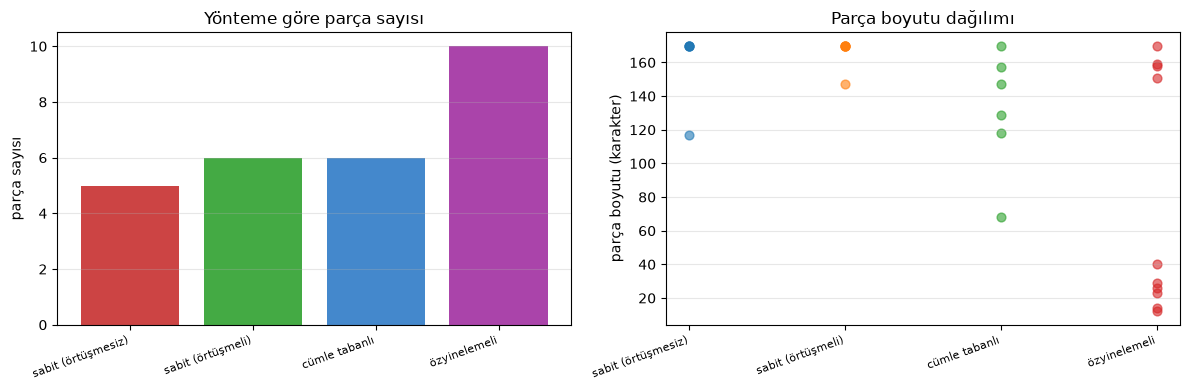

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

adlar = list(yontemler.keys())
sayilar = [len(v) for v in yontemler.values()]

ax[0].bar(range(len(adlar)), sayilar, color=["#c44", "#4a4", "#48c", "#a4a"])
ax[0].set_xticks(range(len(adlar)), adlar, rotation=20, ha="right", fontsize=8)
ax[0].set_ylabel("parça sayısı")
ax[0].set_title("Yönteme göre parça sayısı")
ax[0].grid(alpha=0.3, axis="y")

for i, (ad, parcalar) in enumerate(yontemler.items()):
    boylar = [len(p) for p in parcalar]
    ax[1].scatter([i] * len(boylar), boylar, alpha=0.6, s=40)

ax[1].set_xticks(range(len(adlar)), adlar, rotation=20, ha="right", fontsize=8)
ax[1].set_ylabel("parça boyutu (karakter)")
ax[1].set_title("Parça boyutu dağılımı")
ax[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Tablo ve grafik birlikte okununca durum şöyle:

- **Sabit örtüşmesiz** en az parça üretiyor (5) ama dört kritik bilgiden ikisini
  kaybediyor. Ucuz ama güvenilmez.
- **Sabit örtüşmeli** bir parça fazlaya (6) mal olup bilginin hepsini kurtarıyor.
  Örtüşmenin bedeli bu kadar.
- **Cümle tabanlı** bilgiyi koruyor ama boyutlar 68 ile 170 arasında geziniyor;
  sağdaki grafikte noktaların dağınıklığı bundan.
- **Özyinelemeli** bilgiyi koruyor ama bu hedef boyutta metni en çok parçaya bölen
  yöntem oldu (10 parça, en küçüğü 12 karakter). Sebebi şu: başlıklar kendi
  paragrafları olduğu için tek başlarına birer parçaya dönüştüler.

Son madde beklediğim sonuç değildi ve öğretici oldu: özyinelemeli bölme "en doğal
yerden böl" dediği için, hedef boyut belgenin paragraf yapısına göre küçük kalırsa
metni gereğinden çok parçalıyor. 12 karakterlik bir başlık parçasının tek başına
vektörleştirilmesinin arama açısından pek değeri yok.

Çıkarım: yöntem tek başına yetmiyor, **hedef boyutun belgenin yapısıyla uyumlu
olması** gerekiyor. Gün 15'te yine özyinelemeli yöntemi kullanacağım ama hedef boyutu
paragraflara uyacak şekilde daha büyük seçeceğim.

---

## 7. Adım - Benzerlik metrikleri

Raporda üç metriğin farkını yazdım, şimdi sayısal olarak gösteriyorum.

Kurgu şu: elimde bir soru vektörü ve üç belge vektörü var. Belge C'yi, belge A'nın
**3 katı** olarak seçtim; yani yönü A ile tamamen aynı, sadece daha uzun. Gerçek
hayatta bu "aynı konuyu anlatan ama daha uzun metin" durumuna karşılık geliyor.

Beklentim: iç çarpım uzunluğa kanıp C'yi birinci sıraya koyacak, kosinüs ise A ile
C'yi eşit görecek.

In [10]:
def kosinus(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def ic_carpim(a, b):
    return float(np.dot(a, b))

def oklid(a, b):
    return float(np.linalg.norm(a - b))


soru = np.array([1.0, 0.8, 0.2, 0.0])

belgeler = {
    "A (kısa, alakalı)":      np.array([0.9, 0.7, 0.3, 0.1]),
    "B (kısa, az alakalı)":   np.array([0.2, 0.1, 0.9, 0.8]),
    "C (uzun, A ile aynı yön)": np.array([0.9, 0.7, 0.3, 0.1]) * 3.0,
}

print(f"{'belge':26} {'kosinüs':>9} {'iç çarpım':>11} {'öklid':>8}")
print("-" * 57)
for ad, v in belgeler.items():
    print(f"{ad:26} {kosinus(soru, v):>9.4f} {ic_carpim(soru, v):>11.4f} {oklid(soru, v):>8.4f}")

belge                        kosinüs   iç çarpım    öklid
---------------------------------------------------------
A (kısa, alakalı)             0.9911      1.5200   0.2000
B (kısa, az alakalı)          0.2898      0.4600   1.5033
C (uzun, A ile aynı yön)      0.9911      4.5600   2.2716


Sonuç beklediğim gibi çıktı ve üç metrik **üç farklı cevap** veriyor:

- **Kosinüs:** A ve C tamamen eşit (ikisi de 0.9911). Doğru davranış, çünkü ikisi
  aynı şeyi söylüyor, biri sadece daha uzun.
- **İç çarpım:** C'yi çok öne çıkarıyor (4.56'ya karşı 1.52). Uzunluğa kanmış durumda.
- **Öklid:** C'yi **en uzak** sayıyor (2.27). Yani en alakasız belge olan B'den
  (1.50) bile uzak görüyor. Metin aramasında bu tamamen yanlış bir sonuç.

## 8. Adım - Normalize edersem ne oluyor?

Raporda "vektörler normalize edilmişse üç metrik de aynı sıralamayı verir" demiştim.
Şimdi bütün vektörleri birim uzunluğa getirip tekrar bakıyorum.

In [11]:
def normalize(v):
    return v / np.linalg.norm(v)


soru_n = normalize(soru)
belgeler_n = {ad: normalize(v) for ad, v in belgeler.items()}

print(f"{'belge':26} {'kosinüs':>9} {'iç çarpım':>11} {'öklid':>8}")
print("-" * 57)
for ad, v in belgeler_n.items():
    print(f"{ad:26} {kosinus(soru_n, v):>9.4f} {ic_carpim(soru_n, v):>11.4f} {oklid(soru_n, v):>8.4f}")

print()
print("sıralamalar (en iyiden kötüye):")
for ad, fn, ters in [("kosinüs", kosinus, True), ("iç çarpım", ic_carpim, True),
                     ("öklid", oklid, False)]:
    sirali = sorted(belgeler_n.items(), key=lambda t: round(fn(soru_n, t[1]), 6), reverse=ters)
    print(f"  {ad:11}: {' > '.join(a.split(' ')[0] for a, _ in sirali)}")

belge                        kosinüs   iç çarpım    öklid
---------------------------------------------------------
A (kısa, alakalı)             0.9911      0.9911   0.1333
B (kısa, az alakalı)          0.2898      0.2898   1.1918
C (uzun, A ile aynı yön)      0.9911      0.9911   0.1333

sıralamalar (en iyiden kötüye):
  kosinüs    : A > C > B
  iç çarpım  : A > C > B
  öklid      : A > C > B


Normalize edince:

- Kosinüs ile iç çarpım **birebir aynı sayıyı** veriyor (formüldeki bölen 1 oldu).
- A ile C artık tamamen aynı, çünkü normalize edilince zaten aynı vektöre dönüştüler.
- Üç metrik de aynı sıralamayı üretiyor. Öklid'in sırası ters okunuyor (küçük olan
  iyi) ama sıra aynı.

Son olarak raporda yazdığım matematiksel bağıntıyı doğruluyorum:

```
d² = 2 × (1 - cos)
```

In [12]:
print(f"{'belge':26} {'öklid²':>9} {'2(1-cos)':>10} {'eşit mi':>9}")
print("-" * 57)
for ad, v in belgeler_n.items():
    d2 = oklid(soru_n, v) ** 2
    formul = 2 * (1 - kosinus(soru_n, v))
    print(f"{ad:26} {d2:>9.5f} {formul:>10.5f} {str(abs(d2 - formul) < 1e-9):>9}")

belge                         öklid²   2(1-cos)   eşit mi
---------------------------------------------------------
A (kısa, alakalı)            0.01777    0.01777      True
B (kısa, az alakalı)         1.42045    1.42045      True
C (uzun, A ile aynı yön)     0.01777    0.01777      True


Bağıntı tam olarak tutuyor. Yani normalize edilmiş vektörlerde Öklid uzaklığı ile
kosinüs benzerliği aynı bilginin iki farklı yazılışı; birinden diğerine geçmek için
model çalıştırmaya gerek yok.

---

## Sonuç

**Chunking tarafında** öğrendiklerim:

- Sabit boyutlu örtüşmesiz bölme, bilgi tam kesme noktasına denk gelirse o bilgiyi
  aranamaz hale getiriyor. Dört kritik bilgiden ikisini kaybederek bunu somut olarak
  gördüm.
- Örtüşme bu kaybı önlüyor (4/4), bedeli bir parça fazla ve tekrar eden içerik.
- Cümle tabanlı bölme anlamı koruyor ama boyutları dengesiz.
- Özyinelemeli bölme bilgiyi koruyor, ancak hedef boyut belgenin paragraf yapısına
  göre küçük kalırsa metni gereğinden fazla parçalıyor. Yöntemi seçmek tek başına
  yetmiyor, hedef boyutu da belgeye göre ayarlamak gerekiyor.

**Benzerlik metrikleri tarafında** öğrendiklerim:

- Normalize edilmemiş vektörlerde üç metrik üç farklı sıralama veriyor. İç çarpım
  uzun vektörleri kayırıyor, Öklid aynı yöndeki uzun vektörü en uzak sayıyor.
  Metin aramasında ikisi de yanlış sonuç üretiyor.
- Normalize edilmiş vektörlerde üçü de aynı sıralamayı veriyor; kosinüs ile iç çarpım
  matematiksel olarak aynı şey haline geliyor.
- Bu yüzden asıl soru "hangi metrik" değil, "normalize ediyor muyum". Normalize
  edersem en hızlısını (iç çarpım) seçebiliyorum.